In [1]:
%pip install lightgbm catboost optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # one-liner charts, high-level
import plotly.graph_objects as go # full control chart

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

import optuna

In [3]:
TARGET = "Exited"

categorical_columns = ["Geography", "Gender"]
numerial_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]

drop_columns  = ["id", "CustomerId"]
submission_columns = ["id", "Exited"]

In [4]:
def load_data(option="local"):

  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Bank Churn/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Bank Churn/test.csv')

    train_df['source'] = 'train'
    test_df['source'] = 'test'
    df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

In [5]:
def data_spliter(df):
    train = df[df['source'] == 'train'].drop(columns=drop_columns)
    submission_df = df[df['source'] == 'test'][submission_columns]

    X_train = train_df.drop(columns=[TARGET])
    y_train = train_df[TARGET]

    return X_train, y_train, submission_df

In [6]:
train_df, test_df, df = load_data(option="colab")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA

In [7]:
len(df)

25000

-   **Customer** ID: Уникальный идентификатор каждого клиента.
-   **Surname**: Фамилия клиента.
-   **Credit Score**: Числовое значение, представляющее кредитный рейтинг клиента.
-   **Geography**: Страна проживания клиента (Франция, Испания или Германия).
-   **Gender**: Пол клиента (Мужской или Женский).
-   **Age**: Возраст клиента.
-   **Tenure**: Количество лет, которое клиент обслуживается в банке.
-   **Balance**: Баланс на счёте клиента.
-   **NumOfProducts**: Количество банковских продуктов, которыми пользуется клиент (например, сберегательный счёт, кредитная карта).
-   **HasCrCard**: Наличие кредитной карты у клиента (1 = да, 0 = нет).
-   **IsActiveMember**: Является ли клиент активным членом банка (1 = да, 0 = нет).
-   **EstimatedSalary**: Предполагаемая заработная плата клиента.
-   **Exited**: Ушёл ли клиент (1 = да, 0 = нет).


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               25000 non-null  int64  
 1   CustomerId       25000 non-null  float64
 2   Surname          25000 non-null  object 
 3   CreditScore      25000 non-null  float64
 4   Geography        25000 non-null  object 
 5   Gender           25000 non-null  object 
 6   Age              25000 non-null  float64
 7   Tenure           25000 non-null  float64
 8   Balance          25000 non-null  float64
 9   NumOfProducts    25000 non-null  float64
 10  HasCrCard        25000 non-null  float64
 11  IsActiveMember   25000 non-null  float64
 12  EstimatedSalary  25000 non-null  float64
 13  Exited           15000 non-null  float64
 14  source           25000 non-null  object 
dtypes: float64(10), int64(1), object(4)
memory usage: 2.9+ MB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,25000.0,1.249950e+04,7.217023e+03,0.00,6249.75,12499.50,1.874925e+04,2.499900e+04
CustomerId,25000.0,1.576027e+07,9.833340e+06,15565706.00,15635942.00,15689953.00,1.575763e+07,1.564111e+09
CreditScore,25000.0,6.588129e+02,7.327987e+01,431.00,602.00,662.00,7.090000e+02,8.500000e+02
Age,25000.0,3.770876e+01,8.180639e+00,18.00,32.00,37.00,4.200000e+01,7.400000e+01
Tenure,25000.0,5.038400e+00,2.799650e+00,0.00,3.00,5.00,7.000000e+00,1.000000e+01
Balance,25000.0,4.301952e+04,5.986757e+04,0.00,0.00,0.00,1.099788e+05,2.059620e+05
NumOfProducts,25000.0,1.585920e+00,5.283833e-01,1.00,1.00,2.00,2.000000e+00,4.000000e+00
HasCrCard,25000.0,7.876800e-01,4.089583e-01,0.00,1.00,1.00,1.000000e+00,1.000000e+00
IsActiveMember,25000.0,4.954000e-01,4.999888e-01,0.00,0.00,0.00,1.000000e+00,1.000000e+00
EstimatedSalary,25000.0,1.174967e+05,4.575011e+04,11.58,82870.75,123428.48,1.567749e+05,1.999925e+05


In [10]:
df.isna().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [11]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source
0,0,15653521.0,Nkemakonam,667.0,Germany,Male,33.0,3.0,131769.04,1.0,1.0,1.0,162719.69,0.0,train
1,1,15699005.0,Chiekwugo,614.0,France,Female,31.0,2.0,110615.47,1.0,1.0,1.0,181879.56,0.0,train
2,2,15656912.0,Chiang,683.0,Germany,Female,24.0,6.0,115074.02,2.0,1.0,0.0,109688.82,0.0,train
3,3,15700772.0,Ch'ang,678.0,France,Female,38.0,9.0,0.00,1.0,1.0,0.0,122823.84,1.0,train
4,4,15583850.0,Chiang,588.0,Spain,Female,39.0,3.0,0.00,2.0,1.0,1.0,136910.18,0.0,train


## Pairplot

Text(0.5, 1.02, 'Pairplot of Numerical Features by Churn Status')

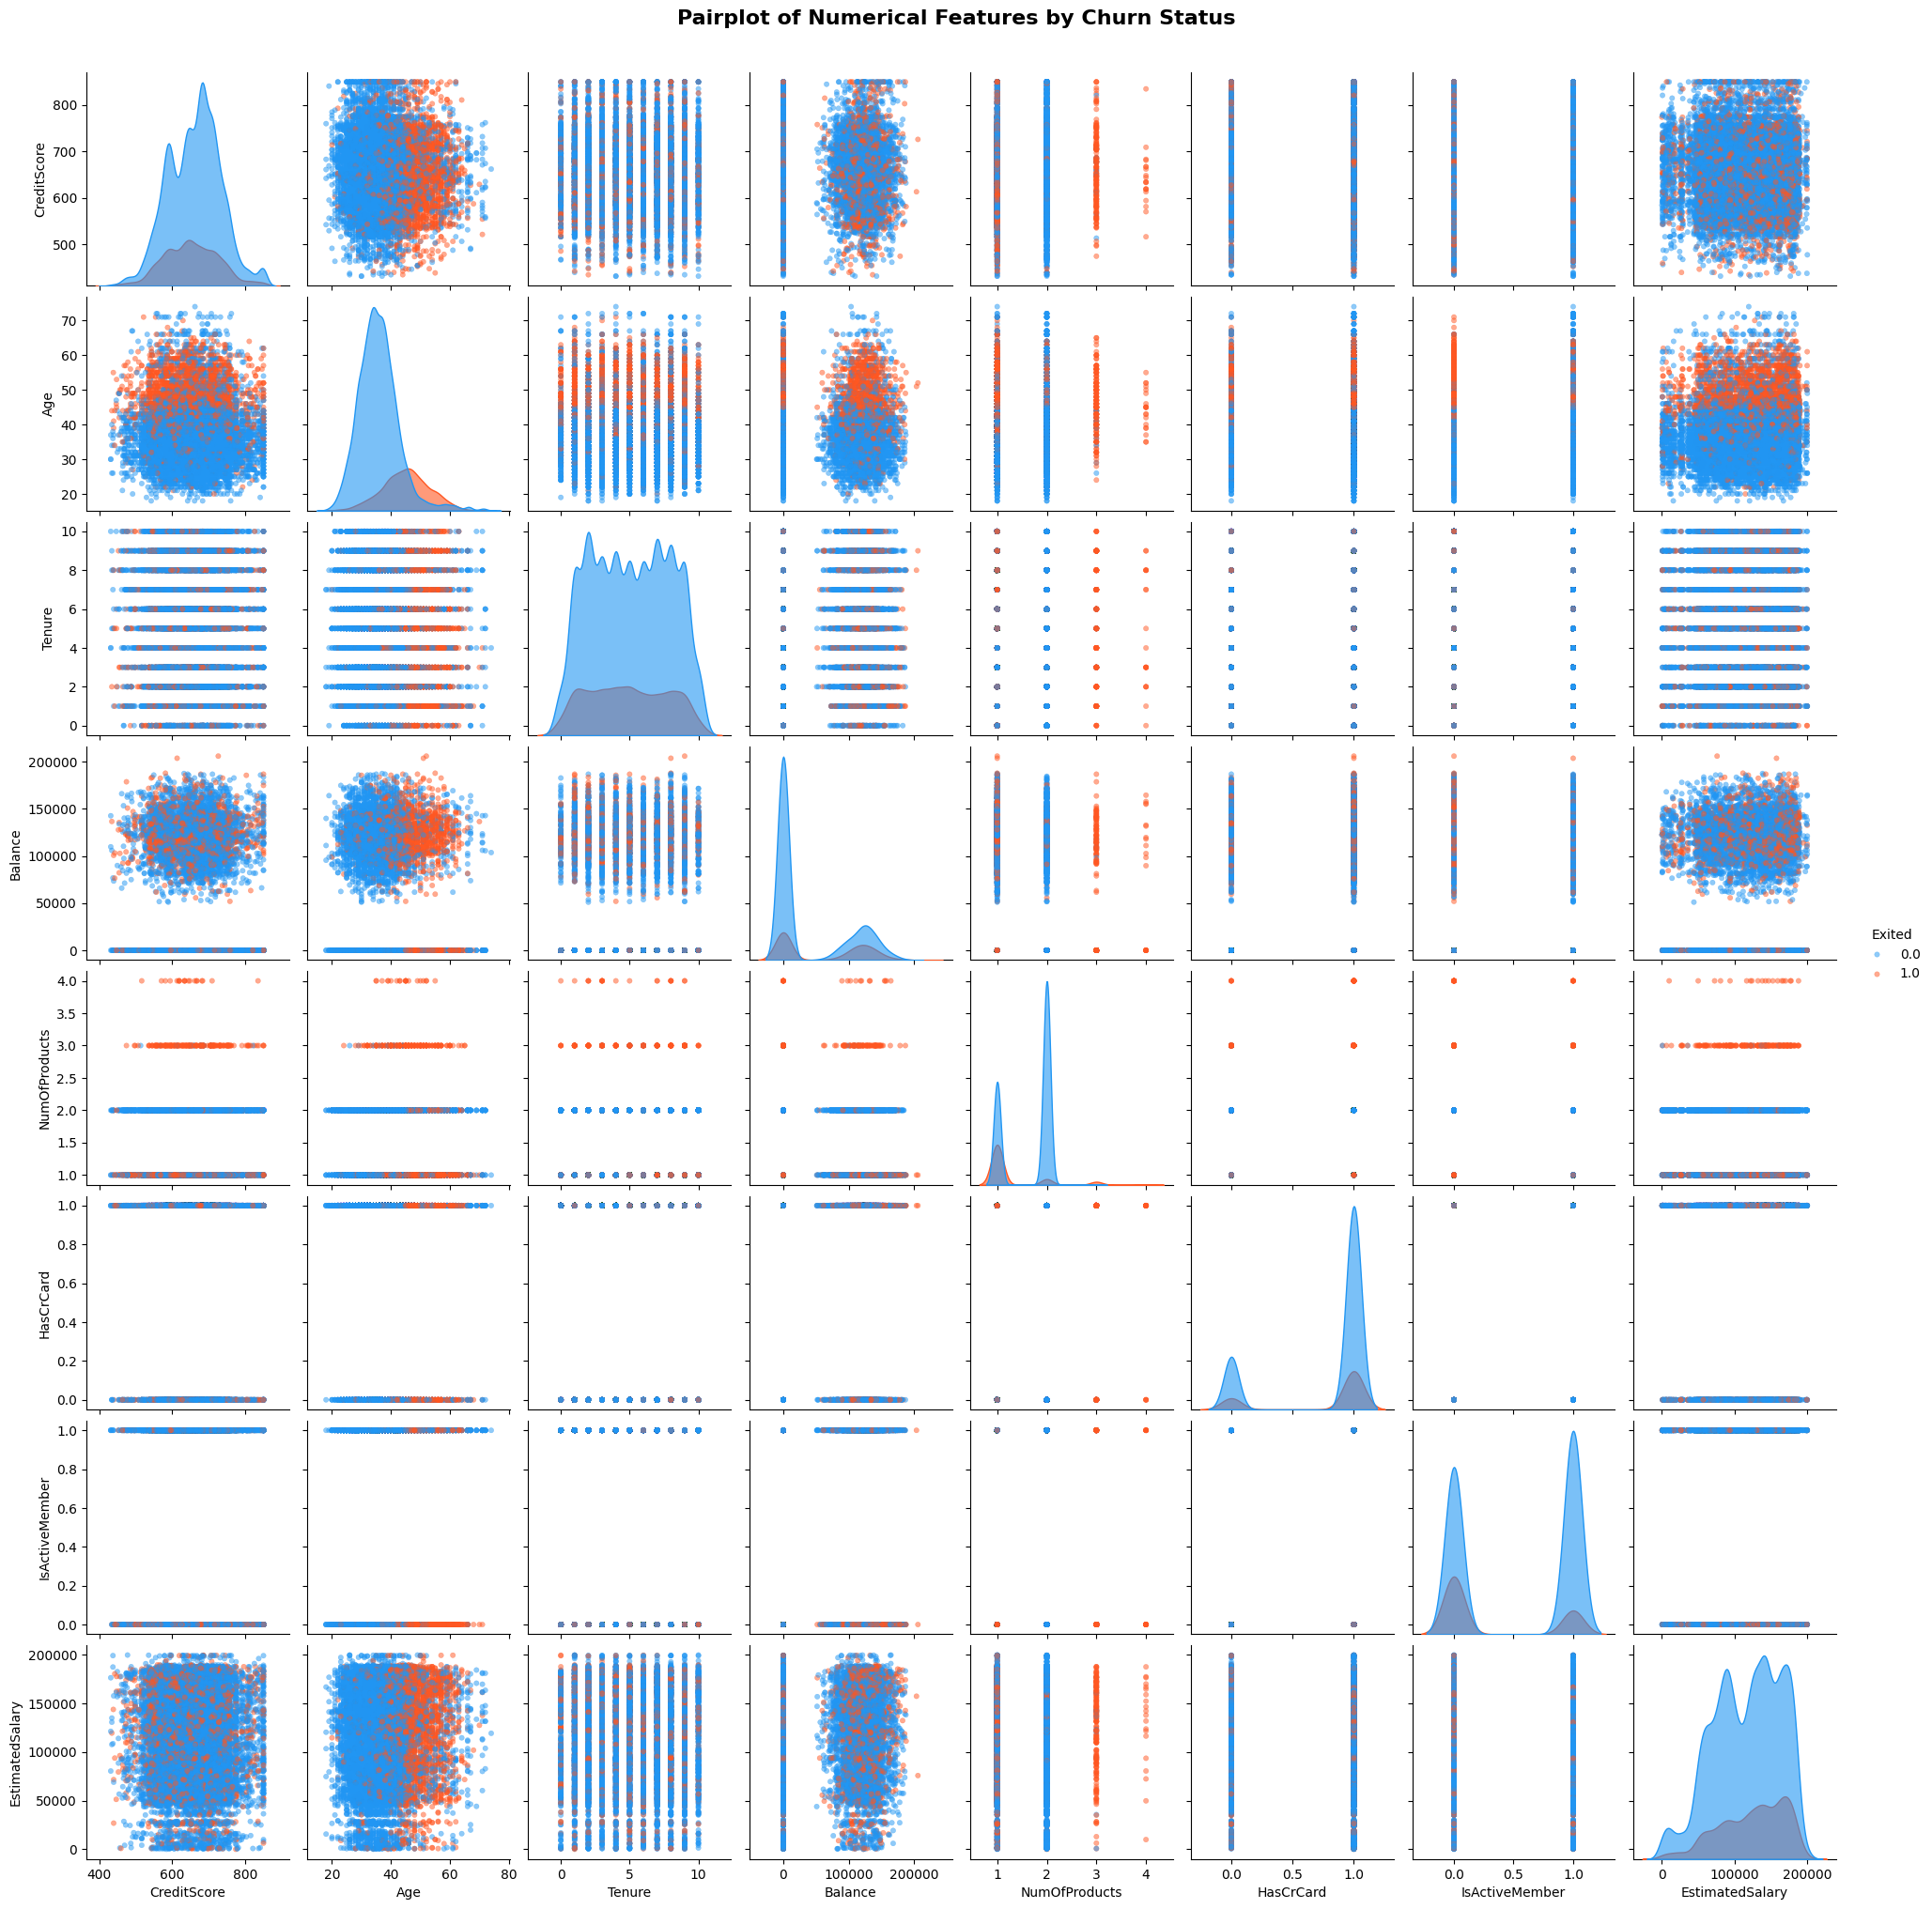

In [12]:
fig = sns.pairplot(
    data=train_df[numerial_columns + [TARGET]],
    hue=TARGET,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15, "edgecolor": None},
    diag_kws={"fill": True, "alpha": 0.6},
    palette={0: "#2196F3", 1: "#FF5722"},
    # corner=True,
)
fig.figure.suptitle("Pairplot of Numerical Features by Churn Status", y=1.02, fontsize=16, fontweight="bold")

## Correlations

<Axes: >

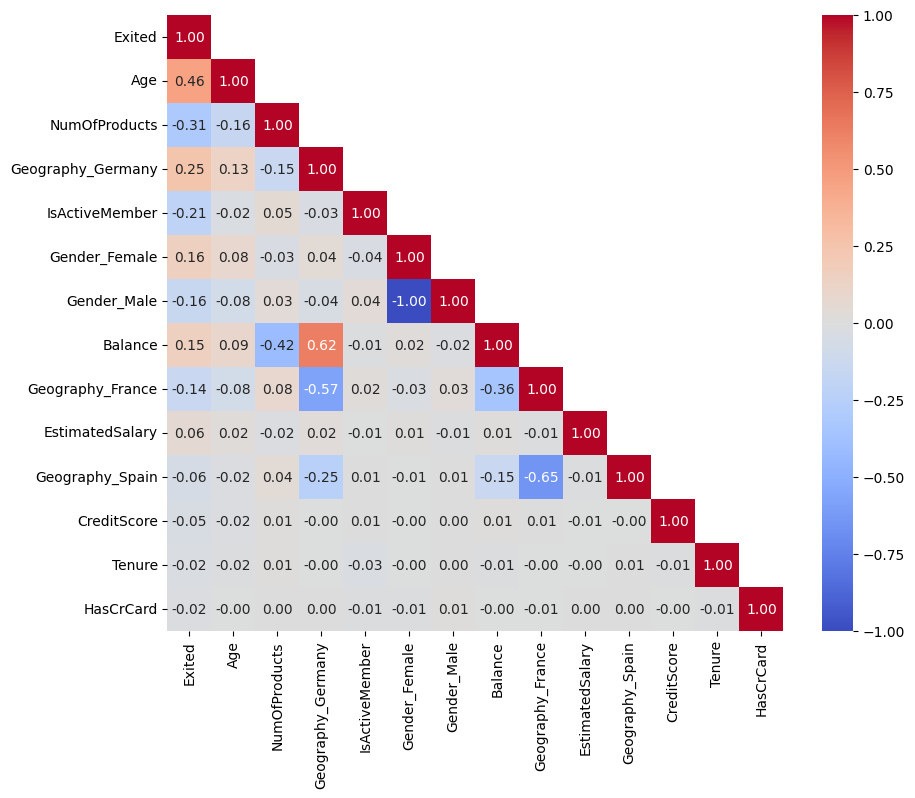

In [80]:
corr_df = pd.get_dummies(
        data=df.drop(columns=drop_columns + ["source"] + ["Surname"]),
        columns=["Gender", "Geography"],
    ).corr()
sorted_columns = corr_df[TARGET].abs().sort_values(ascending=False).index.tolist()
corr_df = corr_df.loc[sorted_columns, sorted_columns]
corr_mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

plt.figure(figsize=(10,8))
sns.heatmap(
    data=corr_df,
    mask=corr_mask,
    annot=True,
    fmt='.2f',
    cmap="coolwarm",
    square=True,
    center=0
)

## Surnames

In [13]:
display(df['Surname'].value_counts().reset_index())

,Surname,count
0,Ch'iu,478
1,Ch'ien,384
2,Ch'ang,376
3,T'ien,320
4,Hsia,306
...,...,...
831,Neumayer,1
832,Ndubuisi,1
833,Zikoranaudodimma,1
834,McIver,1


In [14]:
df[df['Surname'].str.endswith('ov') | df['Surname'].str.endswith('ova') | df['Surname'].str.endswith('ev') | df['Surname'].str.endswith('eva')]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source
18,18,15676094.0,Aksenov,670.0,France,Female,30.0,3.0,0.00,2.0,1.0,0.0,172674.36,0.0,train
20,20,15750121.0,Baryshnikov,619.0,France,Male,34.0,9.0,95830.43,1.0,0.0,1.0,93124.04,0.0,train
93,93,15604044.0,Ozerova,678.0,Spain,Female,40.0,1.0,103099.17,1.0,1.0,1.0,186948.35,0.0,train
138,138,15761487.0,Efimov,679.0,France,Female,54.0,3.0,114419.64,1.0,1.0,0.0,84872.66,1.0,train
208,208,15613014.0,Aksenov,531.0,France,Male,38.0,2.0,0.00,2.0,1.0,0.0,111421.77,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24887,24887,15792989.0,Uvarova,850.0,Spain,Male,39.0,2.0,0.00,2.0,1.0,1.0,81492.80,NaN,test
24926,24926,15736274.0,Ibragimova,684.0,France,Female,26.0,7.0,0.00,2.0,0.0,1.0,88890.05,NaN,test
24946,24946,15605072.0,Shcherbakov,677.0,France,Female,33.0,8.0,0.00,2.0,1.0,1.0,8991.17,NaN,test
24960,24960,15589541.0,Frolov,705.0,Germany,Male,44.0,9.0,131853.46,2.0,1.0,1.0,167553.06,NaN,test


In [15]:
df[df['Surname'].str.contains("?", regex=False)]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source
14,14,15686917.0,Hs?eh,635.0,Spain,Male,48.0,1.0,0.00,2.0,1.0,0.0,125870.50,0.0,train
39,39,15572467.0,L?,685.0,France,Male,39.0,2.0,0.00,2.0,0.0,0.0,118974.77,0.0,train
41,41,15687913.0,H?,599.0,France,Male,29.0,7.0,0.00,2.0,1.0,0.0,27308.58,0.0,train
58,58,15673529.0,K?,674.0,Germany,Male,27.0,9.0,122552.51,2.0,1.0,1.0,175072.47,0.0,train
69,69,15663964.0,K?,576.0,Spain,Male,24.0,5.0,0.00,2.0,0.0,0.0,166640.80,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24880,24880,15750684.0,H?,542.0,France,Male,45.0,2.0,0.00,2.0,1.0,1.0,85536.28,NaN,test
24882,24882,15581528.0,H?,653.0,Germany,Female,46.0,9.0,102874.28,2.0,1.0,0.0,118059.19,NaN,test
24913,24913,15746203.0,Hs?,539.0,Germany,Female,41.0,9.0,110148.49,1.0,0.0,0.0,82820.85,NaN,test
24950,24950,15640855.0,K?,756.0,Spain,Male,45.0,9.0,0.00,2.0,1.0,0.0,88815.25,NaN,test


In [16]:
display(df[df['Surname'].str.contains("'", regex=False)])

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source
3,3,15700772.0,Ch'ang,678.0,France,Female,38.0,9.0,0.00,1.0,1.0,0.0,122823.84,1.0,train
5,5,15636592.0,Ch'ang,678.0,France,Male,34.0,5.0,0.00,2.0,1.0,0.0,171045.35,0.0,train
24,24,15600821.0,Ch'ang,605.0,Spain,Male,50.0,5.0,0.00,1.0,1.0,1.0,76569.64,1.0,train
35,35,15767598.0,Ch'iu,637.0,Germany,Female,36.0,2.0,132623.60,2.0,1.0,1.0,131718.12,0.0,train
36,36,15763665.0,Ch'ang,694.0,France,Female,36.0,8.0,0.00,2.0,1.0,0.0,109355.73,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24980,24980,15616954.0,O'Loghlin,626.0,France,Male,41.0,9.0,127269.75,1.0,1.0,0.0,123587.83,NaN,test
24988,24988,15623595.0,Ch'en,537.0,France,Male,36.0,9.0,0.00,2.0,1.0,1.0,107876.82,NaN,test
24990,24990,15618155.0,Ch'ien,738.0,Spain,Male,37.0,6.0,0.00,2.0,1.0,0.0,139059.05,NaN,test
24994,24994,15613168.0,T'ien,593.0,France,Male,27.0,1.0,0.00,2.0,1.0,1.0,120107.10,NaN,test


## Balance

<Axes: xlabel='Balance', ylabel='Count'>

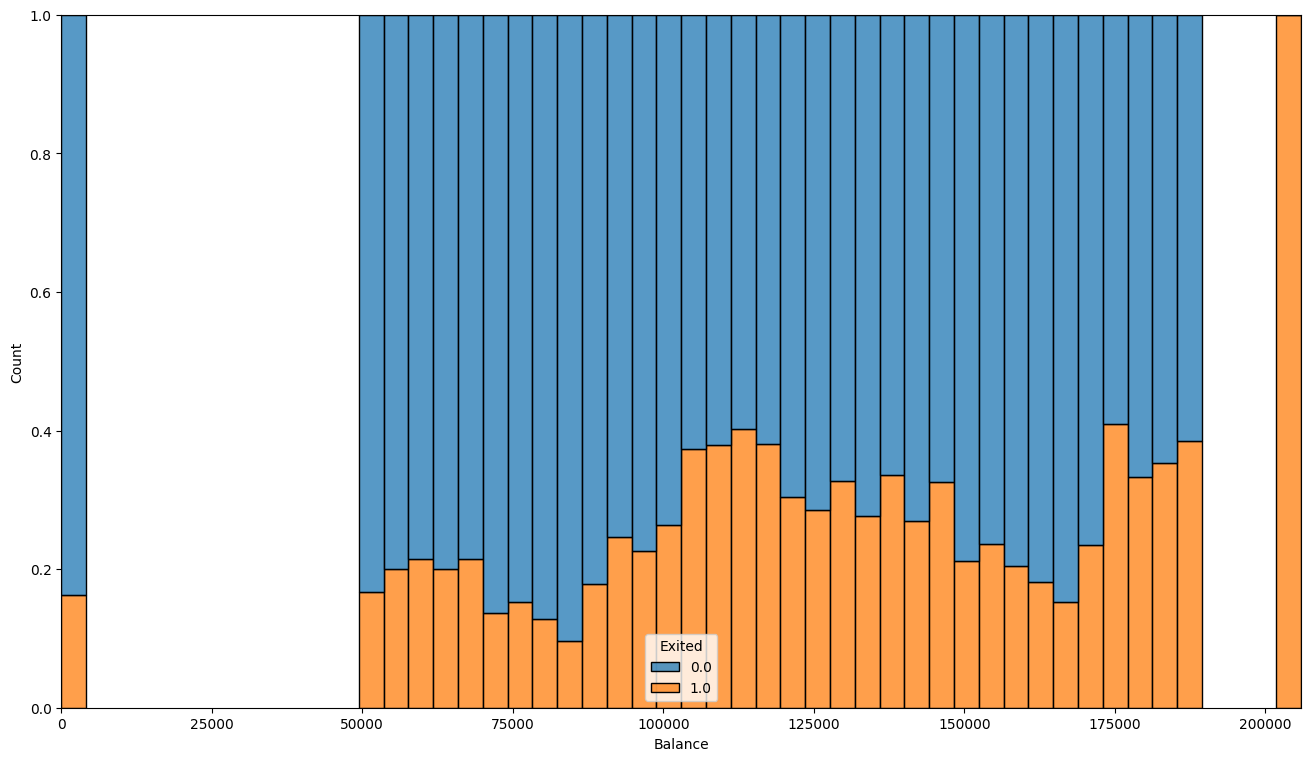

In [17]:
plt.figure(figsize=(16,9))
sns.histplot(
    data=train_df,
    x="Balance",
    hue='Exited',
    bins=50,
    multiple='fill',
)

## Salary

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

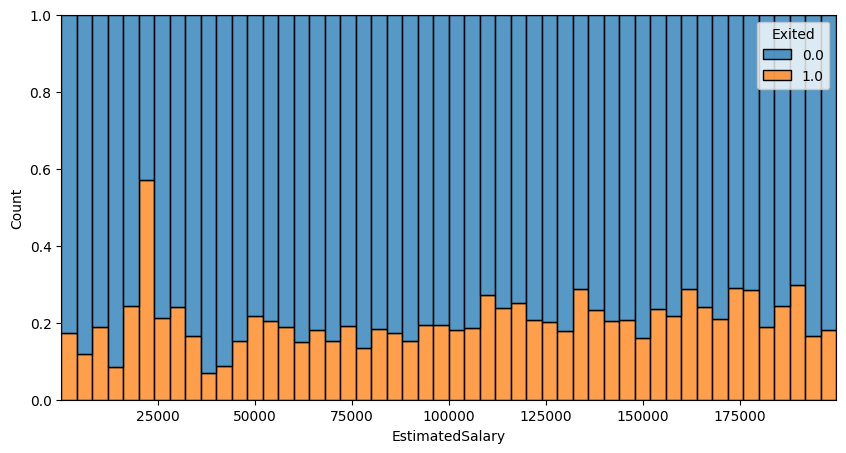

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="EstimatedSalary",
    hue='Exited',
    bins=50,
    multiple='fill',
)

## Age

In [37]:
df['Age'].value_counts().reset_index().sort_values(by='Age').head()

,Age,count
52,18.0,7
48,19.0,15
44,20.0,37
41,21.0,66
36,22.0,111


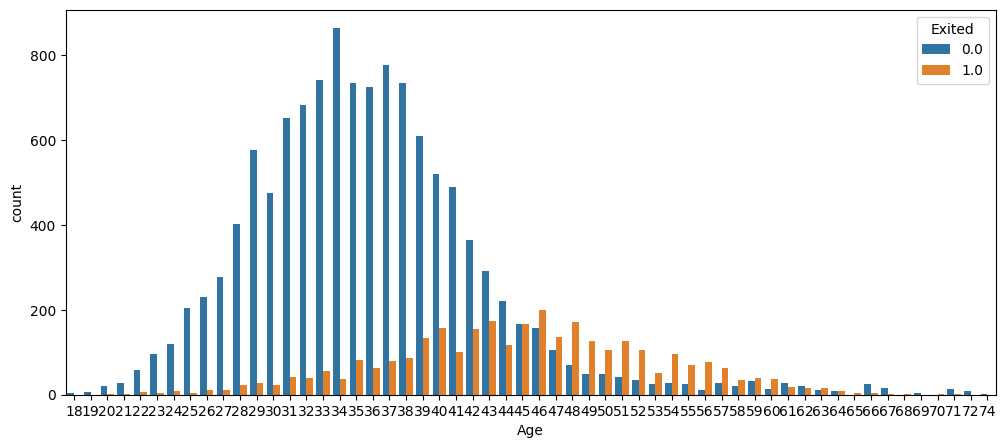

In [19]:
plt.figure(figsize=(12,5))
ax = sns.countplot(
    data=train_df,
    x=df['Age'].astype(int),
    hue='Exited',
)

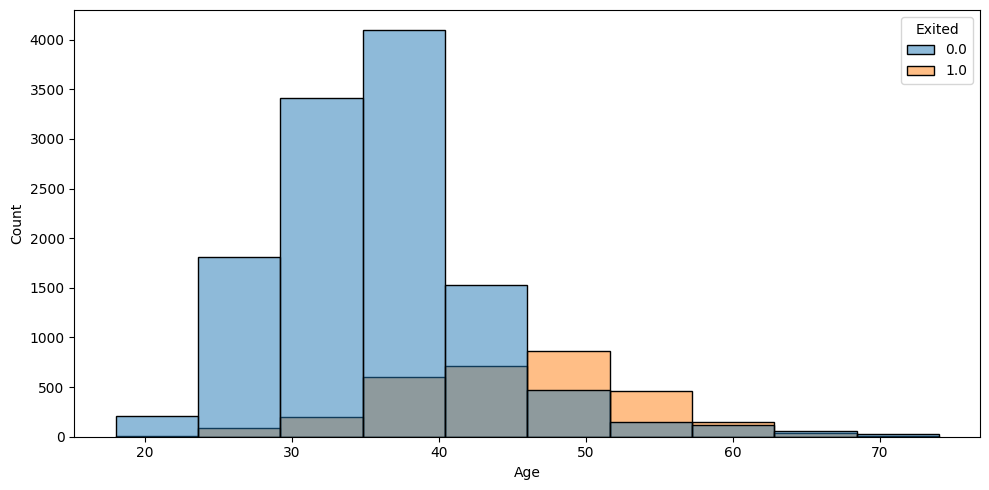

In [88]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="Age",
    hue='Exited',
    bins=10,
    # multiple='fill',
)
# plt.xticks(np.arange(18,75))
plt.tight_layout()

In [96]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

tree = DecisionTreeClassifier(max_leaf_nodes=7, min_samples_leaf=100, random_state=0)
tree.fit(train_df[['Age']], train_df['Exited'])

cuts = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print(cuts)   # e.g. [34.5, 40.5, 45.5, ...]

# train_df['age_bin'] = pd.cut(train_df['Age'], bins=[-np.inf, *cuts, np.inf])
# train_df.groupby('age_bin', observed=True)['Exited'].agg(['mean', 'size'])

[38.5 42.5 44.5 45.5 47.5 60.5]


In [98]:
df.groupby('Age', observed=True)['Exited'].agg(['mean', 'size'])

,mean,size
Age,,
18.0,0.000000,7
19.0,0.000000,15
20.0,0.045455,37
21.0,0.035714,66
22.0,0.093750,111
23.0,0.030612,156
24.0,0.062500,226
25.0,0.014423,322
26.0,0.041841,391


## Credit Score

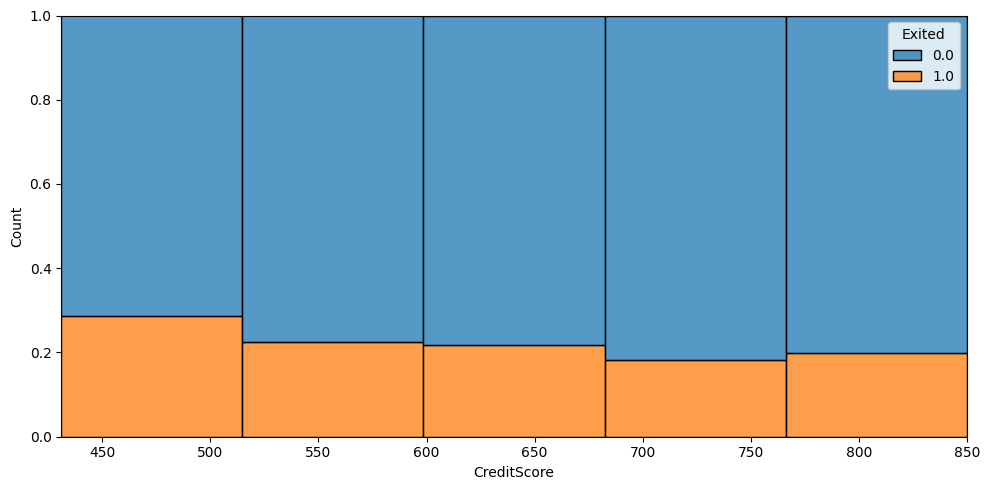

In [85]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="CreditScore",
    hue='Exited',
    bins=5,
    multiple='fill',
)
# plt.xticks(np.arange(18,75))
plt.tight_layout()

# Feature Engineering

In [117]:
def feature_engineering(df):
  original_columns = df.columns.tolist()
  print("Engineering features...")

  # 1. Interaction & Ratio Features
  df['Balance_to_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
  df['Age_to_Tenure_Ratio'] = df['Tenure'] / (df['Age'] + 1)
  df['Products_per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

  # 2. Financial Status & Behavior Indicators
  df['Is_Zero_Balance'] = (df['Balance'] == 0).astype(int)

  # # CreditScore Binning
  # score_bins = [0, 579, 669, 739, 799, 850]
  # score_labels = ['Very_Poor', 'Fair', 'Good', 'Very_Good', 'Exceptional']
  # df['CreditScore_Segment'] = pd.cut(df['CreditScore'], bins=score_bins, labels=score_labels).astype(str)

  # # Age Binning (targeting the peak churn between 45 and 60)
  # age_bins = [0, 30, 45, 60, 100]
  # age_labels = ['Under_30', '30_to_45', '45_to_60', 'Over_60']
  # df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels).astype(str)

  # 3. Engagement Score
  df['Customer_Activity_Index'] = df['HasCrCard'] + df['IsActiveMember'] + (df['NumOfProducts'] > 1).astype(int)

  # 4. Surname & Demographic Patterns
  # Surname length and special character rules
  df['Surname_Has_Question'] = df['Surname'].str.contains('?', regex=False).astype(int)

  # Endings often representing specific ethnicities/families in synthetic datasets
  df['Surname_Ends_With_Slavic'] = df['Surname'].str.endswith(('ov', 'ova', 'ev', 'eva')).astype(int)

  engineered_features = [k for k in df.columns.tolist() if k not in original_columns]

  print(f"\nAdded {len(engineered_features)} features")
  print(f"Features added:")
  for idx, f in enumerate(engineered_features):
    print(f"{idx + 1}: {f}")
  return df

In [119]:
test = feature_engineering(df)

Engineering features...

Added 7 features
Features added:
1: Balance_to_Salary_Ratio
2: Age_to_Tenure_Ratio
3: Products_per_Tenure
4: Is_Zero_Balance
5: Customer_Activity_Index
6: Surname_Has_Question
7: Surname_Ends_With_Slavic
